### 多臂老虎机问题  
k个老虎机拉杆，每个拉杆的奖励概率分布不同（如p不同的伯努利分布），操作T次，找到最优的杠杆并实现最高的奖励


**尝试 -> r**  
↓  
`[1]    [2]    ...    [i]    ...    [k]`   
`Q₁=0   Q₂=0   ...    Qᵢ=r   ...    Qₖ=0`

---

- **$\epsilon$ 随机选择**
- **$1-\epsilon$ 选当前最大 $\hat{Q}(a)$**
  $$ \arg\max_{a \in A} \hat{Q}(a) $$

↓

> 实验后期, 最优拉杆基本确定, $\epsilon$ 可以减小。

---

令 $\epsilon = 1/t$

↓

**缩小懊悔, 提高奖励。**

随机生成了一个10臂伯努利老虎机
获奖概率最大的拉杆为5号,其获奖概率为0.9756
epsilon-贪婪算法的累积懊悔为： 14.234955101910678
epsilon-贪婪算法的累积奖励为： 4866.0
贪婪参数为： 0.01
策略为： [1, 9, 8, 0, 2, 8, 2, 3, 3, 3, 3, 3, 3, 7, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 9, 9, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 

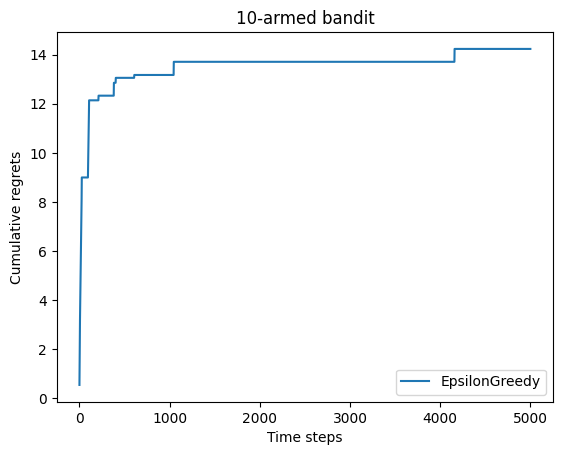

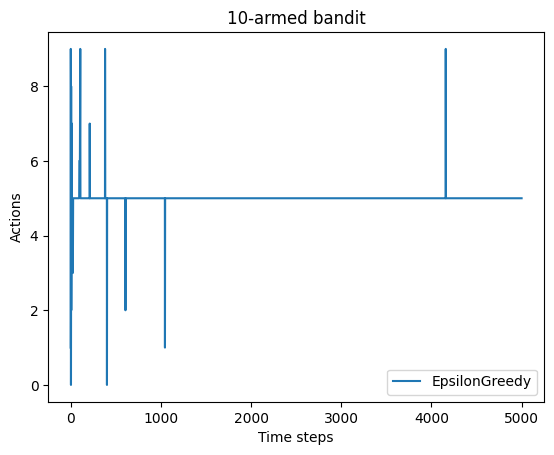

In [12]:
# 导入需要使用的库,其中numpy是支持数组和矩阵运算的科学计算库,而matplotlib是绘图库
import numpy as np
import matplotlib.pyplot as plt


class BernoulliBandit:
    """ 伯努利多臂老虎机,输入K表示拉杆个数 """
    def __init__(self, K):
        self.rng = rng
        self.probs = self.rng.uniform(size=K)  # 随机生成K个0～1的数,作为拉动每根拉杆的获奖,size = K相当于生成一个有K个元素的一维数组
        # 概率
        self.best_idx = np.argmax(self.probs)  # 获奖概率最大的拉杆
        self.best_prob = self.probs[self.best_idx]  # 最大的获奖概率
        self.K = K

    def step(self, k):
        # 当玩家选择了k号拉杆后,根据拉动该老虎机的k号拉杆获得奖励的概率返回1（获奖）或0（未
        # 获奖）
        if self.rng.random() < self.probs[k]:
            return 1
        else:
            return 0




class Solver:
    """ 多臂老虎机算法基本框架 """
    def __init__(self, bandit):
        self.bandit = bandit  # 多臂老虎机实例，相当于BernoulliBandit的一个实例
        self.counts = np.zeros(self.bandit.K)  # 每根拉杆的尝试次数，一维数组
        self.regret = 0.  # 当前步的累积懊悔
        self.reward = 0.  # 当前步的累积奖励
        self.actions = []  # 维护一个列表,记录每一步的动作
        self.regrets = []  # 维护一个列表,记录每一步的累积懊悔
        

    def update_regret(self, k):
        # 计算累积懊悔并保存,k为本次动作选择的拉杆的编号
        self.regret += self.bandit.best_prob - self.bandit.probs[k]  #因为用的是伯努利分布,所以每次奖励的期望就是获奖概率
        self.regrets.append(self.regret)
    def update_reward(self, k):
        # 计算累积奖励并保存,k为本次动作选择的拉杆的编号
        r = self.bandit.step(k)
        self.reward += r
        # self.rewards.append(self.reward)
    def run_one_step(self):
        # 返回当前动作选择哪一根拉杆,由每个具体的策略实现
        raise NotImplementedError
        #提示使用者该方法需要在子类中实现，在基类中未实现

    def run(self, num_steps):
        # 运行一定次数,num_steps为总运行次数
        for _ in range(num_steps):  # _表示只关心循环次数，不关心索引值，每次循环中执行以下操作，_表示占位符
            k = self.run_one_step()
            self.counts[k] += 1  # 更新选择k号拉杆的次数，用于后续计算期望
            self.actions.append(int(k))
            self.update_regret(k)
            self.update_reward(k)

class EpsilonGreedy(Solver):
    """ epsilon贪婪算法,继承Solver类 """
    def __init__(self, bandit, epsilon=0.01, init_prob=1.0):
        super(EpsilonGreedy, self).__init__(bandit)  # 初始化父类，调用父类的构造函数，相当于把bandit的值传给solver
        self.epsilon = epsilon
        #初始化拉动所有拉杆的期望奖励估值
        self.estimates = np.array([init_prob] * self.bandit.K)
        self.total_count = 0  # 记录总的动作次数

    def run_one_step(self):
        self.total_count += 1
        if rng.random() < 1/(self.total_count):
            k = rng.integers(0, self.bandit.K)  # 随机选择一根拉杆
        else:
            # #找到所有等于最大值的索引（返回一维整数数组）
            # candidates = np.flatnonzero(self.estimates == self.estimates.max())

            # # 用 bandit 的 Generator 随机从候选中选一个（可复现）
            # k = self.bandit.rng.choice(candidates)
            k = np.argmax(self.estimates)  # 选择期望奖励估值最大的拉杆，返回其索引
        r = self.bandit.step(k)  # 得到本次动作的奖励
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])  #1.使得除数结果为浮点数
        return k

def plot_results(solvers, solver_names):
    """生成累积懊悔随时间变化的图像。输入solvers是一个列表,列表中的每个元素是一种特定的策略。
    而solver_names也是一个列表,存储每个策略的名称"""
    for idx, solver in enumerate(solvers):
        #enumerate函数用于将一个可遍历的数据对象(如列表、元组或字符串)组合为一个索引序列,同时列出数据和数据下标
        time_list = range(len(solver.regrets))
        plt.plot(time_list, solver.regrets, label=solver_names[idx])
    plt.xlabel('Time steps')
    plt.ylabel('Cumulative regrets')
    plt.title('%d-armed bandit' % solvers[0].bandit.K)
    plt.legend()
    plt.show()

def plot_schedule(solvers, solver_names):
    """生成每一步选择拉杆的图像。输入solvers是一个列表,列表中的每个元素是一种特定的策略。
    而solver_names也是一个列表,存储每个策略的名称"""
    for idx, solver in enumerate(solvers):
        time_list = range(len(solver.actions))
        plt.plot(time_list, solver.actions, label=solver_names[idx])
    plt.xlabel('Time steps')
    plt.ylabel('Actions')
    plt.title('%d-armed bandit' % solvers[0].bandit.K)
    plt.legend()
    plt.show()

rng = np.random.default_rng(42)
K = 10
bandit_10_arm = BernoulliBandit(K)
print("随机生成了一个%d臂伯努利老虎机" % K)
print("获奖概率最大的拉杆为%d号,其获奖概率为%.4f" %
      (bandit_10_arm.best_idx, bandit_10_arm.best_prob))

epsilon_greedy_solver = EpsilonGreedy(bandit_10_arm)
epsilon_greedy_solver.run(5000)
print('epsilon-贪婪算法的累积懊悔为：', epsilon_greedy_solver.regret)
print('epsilon-贪婪算法的累积奖励为：', epsilon_greedy_solver.reward)
print("贪婪参数为：", epsilon_greedy_solver.epsilon)
print("策略为：", epsilon_greedy_solver.actions)
plot_results([epsilon_greedy_solver], ["EpsilonGreedy"])
plot_schedule([epsilon_greedy_solver], ["EpsilonGreedy"])
# epsilons = [1e-4, 0.01, 0.1, 0.25, 0.5]
# epsilon_greedy_solver_list = [
#     EpsilonGreedy(bandit_10_arm, epsilon=e) for e in epsilons
# ]
# epsilon_greedy_solver_names = ["epsilon={}".format(e) for e in epsilons]
# for solver in epsilon_greedy_solver_list:
#     solver.run(5000)

# plot_results(epsilon_greedy_solver_list, epsilon_greedy_solver_names)
# plot_schedule(epsilon_greedy_solver_list, epsilon_greedy_solver_names)

# 马尔可夫决策过程

In [ ]:
import numpy as np
rng = np.random.default_rng(42)

P = [
    [0.9, 0.1, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.0, 0.4],
    [0.0, 0.0, 0.0, 0.0, 0.3, 0.7],
    [0.0, 0.2, 0.3, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]
P = np.array(P)  #转换为numpy数组
rewards = [-1,-2,-2,10,1,0] #第六个状态是终止状态，所以奖励为0
gamma = 0.5

def compute_return(start_index, chain, gamma):
    G = 0
    for i in reversed(range(start_index, len(chain))): #从后往前遍历，计算到某个索引为止的回报
        G = gamma * G + rewards[chain[i] - 1]
    return G


# 一个状态序列,s1-s2-s3-s6
chain = [1, 2, 3, 6]
start_index = 0
G = compute_return(start_index, chain, gamma)
print("根据本序列计算得到回报为：%s。" % G)

def compute(P, rewards, gamma, states_num):
    #计算状态价值函数的解析解
    ''' 利用贝尔曼方程的矩阵形式计算解析解,states_num是MRP的状态数 '''
    rewards = np.array(rewards).reshape((-1, 1))  #将rewards写成列向量形式,-1表示行数自动计算，1表示列数为1,转化为列向量
    value = np.dot(np.linalg.inv(np.eye(states_num, states_num) - gamma * P),
                   rewards)
    return value


V = compute(P, rewards, gamma, 6)
print("MRP中每个状态价值分别为\n", V)

S = ["s1", "s2", "s3", "s4", "s5"]  # 状态集合
A = ["保持s1", "前往s1", "前往s2", "前往s3", "前往s4", "前往s5", "概率前往"]  # 动作集合
# 状态转移函数，重新定义了状态转移概率，意思是：s1-保持s1，那么下一个状态为s1的概率为1，状态转移函数结合策略就变成了MRP
P = {
    "s1-保持s1-s1": 1.0,
    "s1-前往s2-s2": 1.0,
    "s2-前往s1-s1": 1.0,
    "s2-前往s3-s3": 1.0,
    "s3-前往s4-s4": 1.0,
    "s3-前往s5-s5": 1.0,
    "s4-前往s5-s5": 1.0,
    "s4-概率前往-s2": 0.2,
    "s4-概率前往-s3": 0.4,
    "s4-概率前往-s4": 0.4,
}
# 奖励函数
R = {
    "s1-保持s1": -1,
    "s1-前往s2": 0,
    "s2-前往s1": -1,
    "s2-前往s3": -2,
    "s3-前往s4": -2,
    "s3-前往s5": 0,
    "s4-前往s5": 10,
    "s4-概率前往": 1,
}
gamma = 0.5  # 折扣因子
MDP = (S, A, P, R, gamma)#打包为一个元组

# 策略1,随机策略
Pi_1 = {
    "s1-保持s1": 0.5,
    "s1-前往s2": 0.5,
    "s2-前往s1": 0.5,
    "s2-前往s3": 0.5,
    "s3-前往s4": 0.5,
    "s3-前往s5": 0.5,
    "s4-前往s5": 0.5,
    "s4-概率前往": 0.5,
}
# 策略2
Pi_2 = {
    "s1-保持s1": 0.6,
    "s1-前往s2": 0.4,
    "s2-前往s1": 0.3,
    "s2-前往s3": 0.7,
    "s3-前往s4": 0.5,
    "s3-前往s5": 0.5,
    "s4-前往s5": 0.1,
    "s4-概率前往": 0.9,
}


# 把输入的两个字符串通过“-”连接,便于使用上述定义的P、R变量
def join(str1, str2):
    return str1 + '-' + str2

gamma = 0.5
# 转化后的MRP的状态转移矩阵
P_from_mdp_to_mrp = [
    [0.5, 0.5, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.5, 0.5],
    [0.0, 0.1, 0.2, 0.2, 0.5],
    [0.0, 0.0, 0.0, 0.0, 1.0],
]
P_from_mdp_to_mrp = np.array(P_from_mdp_to_mrp)
R_from_mdp_to_mrp = [-0.5, -1.5, -1.0, 5.5, 0]  # 转化后的MRP的奖励函数，是对某一状态所有策略下奖励的期望

V = compute(P_from_mdp_to_mrp, R_from_mdp_to_mrp, gamma, 5)
print("MDP中每个状态价值分别为\n", V)

#定义采样函数，根据MDP和策略Pi采样序列，返回采样得到的多个序列，是采用蒙特卡洛法的基础
def sample(MDP, Pi, timestep_max, number):
    ''' 采样函数,策略Pi,限制最长时间步timestep_max,总共采样序列数number '''
    S, A, P, R, gamma = MDP
    #元组按位置拆包赋值给变量
    episodes = []
    for _ in range(number):
        episode = []
        timestep = 0
        s = S[np.random.randint(4)]  # 随机选择一个除s5以外的状态s作为起点
        # 当前状态为终止状态或者时间步太长时,一次采样结束
        while s != "s5" and timestep <= timestep_max:
            timestep += 1
            rand, temp = np.random.rand(), 0
            # 在状态s下根据策略选择动作
            for a_opt in A:
                temp += Pi.get(join(s, a_opt), 0)
                #temp为状态和动作对应的概率，没有的话就是0
                if temp > rand:
                    a = a_opt
                    r = R.get(join(s, a), 0)
                    break
            rand, temp = np.random.rand(), 0
            # 根据状态转移概率得到下一个状态s_next
            for s_opt in S:
                temp += P.get(join(join(s, a), s_opt), 0)
                if temp > rand:
                    s_next = s_opt
                    break
            episode.append((s, a, r, s_next))  # 把（s,a,r,s_next）元组放入序列中
            s = s_next  # s_next变成当前状态,开始接下来的循环
        episodes.append(episode)
    return episodes


# 采样5次,每个序列最长不超过20步
episodes = sample(MDP, Pi_1, 20, 5)
print('第一条序列\n', episodes[0])
print('第二条序列\n', episodes[1])
print('第五条序列\n', episodes[4])

# 对所有采样序列计算所有状态的价值
def MC(episodes, V, N, gamma):
    for episode in episodes:
        G = 0
        for i in range(len(episode) - 1, -1, -1):  #一个序列从后往前计算，从最后一个元素到第一个元素，终止位置是-1，因此会遍历到0
            (s, a, r, s_next) = episode[i]
            G = r + gamma * G
            N[s] = N[s] + 1
            V[s] = V[s] + (G - V[s]) / N[s]


timestep_max = 20
# 采样1000次,可以自行修改
episodes = sample(MDP, Pi_1, timestep_max, 1000)
gamma = 0.5
V = {"s1": 0, "s2": 0, "s3": 0, "s4": 0, "s5": 0}
N = {"s1": 0, "s2": 0, "s3": 0, "s4": 0, "s5": 0}
MC(episodes, V, N, gamma)
print("使用蒙特卡洛方法计算MDP的状态价值为\n", V)


根据本序列计算得到回报为：-2.5。
MRP中每个状态价值分别为
 [[-2.01950168]
 [-2.21451846]
 [ 1.16142785]
 [10.53809283]
 [ 3.58728554]
 [ 0.        ]]
MDP中每个状态价值分别为
 [[-1.22555411]
 [-1.67666232]
 [ 0.51890482]
 [ 6.0756193 ]
 [ 0.        ]]
第一条序列
 [('s3', '前往s5', 0, 's5')]
第二条序列
 [('s3', '前往s5', 0, 's5')]
第五条序列
 [('s2', '前往s1', -1, 's1'), ('s1', '保持s1', -1, 's1'), ('s1', '前往s2', 0, 's2'), ('s2', '前往s3', -2, 's3'), ('s3', '前往s5', 0, 's5')]
使用蒙特卡洛方法计算MDP的状态价值为
 {'s1': -1.2133737018808284, 's2': -1.6966127356544882, 's3': 0.5025496395818329, 's4': 5.896550857365253, 's5': 0}


# 动态规划算法
### 价值迭代 
### 策略迭代

In [1]:
import copy


class CliffWalkingEnv:
    """ 悬崖漫步环境"""
    def __init__(self, ncol=12, nrow=4):
        self.ncol = ncol  # 定义网格世界的列
        self.nrow = nrow  # 定义网格世界的行
        # 转移矩阵P[state][action] = [(p, next_state, reward, done)]包含下一个状态和奖励
        self.P = self.createP()

    def createP(self):
        # 初始化
        P = [[[] for j in range(4)] for i in range(self.nrow * self.ncol)]
        '''
        48个列表对应48个格子,每个列表里有四个空列表
        '''
        # 4种动作, change[0]:上,change[1]:下, change[2]:左, change[3]:右。坐标系原点(0,0)
        # 定义在左上角
        change = [[0, -1], [0, 1], [-1, 0], [1, 0]]
        for i in range(self.nrow):
            for j in range(self.ncol):
                for a in range(4):
                    # 位置在悬崖或者目标状态,因为无法继续交互,任何动作奖励都为0
                    if i == self.nrow - 1 and j > 0:
                        #P的第i * self.ncol + j个元素对应第i行第j列的格子，a对应格子里的第a个元组，表示对应不同动作的下一个位置。这里相当于在边缘处，处于悬崖或者终点，交互不继续
                        P[i * self.ncol + j][a] = [(1, i * self.ncol + j, 0,
                                                    True)]
                        continue
                    # 其他位置
                    next_x = min(self.ncol - 1, max(0, j + change[a][0]))#判断下一个位置的行坐标，不能比0小，不能比12大
                    next_y = min(self.nrow - 1, max(0, i + change[a][1]))
                    next_state = next_y * self.ncol + next_x
                    reward = -1
                    done = False
                    # 下一个位置在悬崖或者终点
                    if next_y == self.nrow - 1 and next_x > 0:
                        done = True
                        if next_x != self.ncol - 1:  # 下一个位置在悬崖
                            reward = -100
                    P[i * self.ncol + j][a] = [(1, next_state, reward, done)]
                    #第一位是概率，由于这个不是冰湖问题，故采用相应的策略一定会移动到相应的格子上
        return P
    
class PolicyIteration:
    """ 策略迭代算法 """
    def __init__(self, env, theta, gamma):
        self.env = env
        self.v = [0] * self.env.ncol * self.env.nrow  # 初始化价值为0
        self.pi = [[0.25, 0.25, 0.25, 0.25] for i in range(self.env.ncol * self.env.nrow)]  # 初始化为均匀随机策略,每个动作的概率都是0.25
        self.theta = theta  # 策略评估收敛阈值
        self.gamma = gamma  # 折扣因子

    def policy_evaluation(self):  # 策略评估
        cnt = 1  # 计数器
        while 1:
            max_diff = 0
            new_v = [0] * self.env.ncol * self.env.nrow
            #初始化新一轮的状态价值函数，用来存储本轮计算得到的状态价值函数
            for s in range(self.env.ncol * self.env.nrow):
                qsa_list = []  # 开始计算状态s下的所有Q(s,a)价值
                for a in range(4):
                    qsa = 0
                    for res in self.env.P[s][a]:
                        p, next_state, r, done = res
                        qsa += p * (r + self.gamma * self.v[next_state] * (1 - done))
                        # 本章环境比较特殊,奖励和下一个状态有关,所以需要和状态转移概率相乘,而由于不是冰湖问题，状态转移概率为1
                    qsa_list.append(self.pi[s][a] * qsa)
                new_v[s] = sum(qsa_list)  # 状态价值函数和动作价值函数之间的关系
                max_diff = max(max_diff, abs(new_v[s] - self.v[s]))
            self.v = new_v
            if max_diff < self.theta: break  # 满足收敛条件,退出评估迭代
            cnt += 1
        print("策略评估进行%d轮后完成" % cnt)

    def policy_improvement(self):  # 策略提升
        for s in range(self.env.nrow * self.env.ncol):
            qsa_list = []
            for a in range(4):
                qsa = 0
                for res in self.env.P[s][a]:
                    p, next_state, r, done = res
                    qsa += p * (r + self.gamma * self.v[next_state] * (1 - done))
                qsa_list.append(qsa)
            maxq = max(qsa_list)
            cntq = qsa_list.count(maxq)  # 计算有几个动作得到了最大的Q值
            # 让这些动作均分概率
            self.pi[s] = [1 / cntq if q == maxq else 0 for q in qsa_list]
        print("策略提升完成")
        return self.pi

    def policy_iteration(self):  # 策略迭代
        while 1:
            self.policy_evaluation()
            old_pi = copy.deepcopy(self.pi)  # 将列表进行深拷贝,方便接下来进行比较
            new_pi = self.policy_improvement()
            if old_pi == new_pi: break

def print_agent(agent, action_meaning, disaster=[], end=[]):
    print("状态价值：")
    for i in range(agent.env.nrow):
        for j in range(agent.env.ncol):
            # 为了输出美观,保持输出6个字符
            print('%6.6s' % ('%.3f' % agent.v[i * agent.env.ncol + j]), end=' ')
        print()

    print("策略：")
    for i in range(agent.env.nrow):
        for j in range(agent.env.ncol):
            # 一些特殊的状态,例如悬崖漫步中的悬崖
            if (i * agent.env.ncol + j) in disaster:
                print('****', end=' ')
            elif (i * agent.env.ncol + j) in end:  # 目标状态
                print('EEEE', end=' ')
            else:
                a = agent.pi[i * agent.env.ncol + j]
                pi_str = ''
                for k in range(len(action_meaning)):
                    pi_str += action_meaning[k] if a[k] > 0 else 'o'
                print(pi_str, end=' ')
        print()


env = CliffWalkingEnv()
action_meaning = ['^', 'v', '<', '>']
theta = 0.001
gamma = 0.9
agent = PolicyIteration(env, theta, gamma)
agent.policy_iteration()
print_agent(agent, action_meaning, list(range(37, 47)), [47])

class ValueIteration:
    """ 价值迭代算法 """
    def __init__(self, env, theta, gamma):
        self.env = env
        self.v = [0] * self.env.ncol * self.env.nrow  # 初始化价值为0
        self.theta = theta  # 价值收敛阈值
        self.gamma = gamma
        # 价值迭代结束后得到的策略
        self.pi = [None for i in range(self.env.ncol * self.env.nrow)]

    def value_iteration(self):
        cnt = 0
        while 1:
            max_diff = 0
            new_v = [0] * self.env.ncol * self.env.nrow
            for s in range(self.env.ncol * self.env.nrow):
                qsa_list = []  # 开始计算状态s下的所有Q(s,a)价值
                for a in range(4):
                    qsa = 0
                    for res in self.env.P[s][a]:
                        p, next_state, r, done = res
                        qsa += p * (r + self.gamma * self.v[next_state] * (1 - done))
                    qsa_list.append(qsa)  # 这一行和下一行代码是价值迭代和策略迭代的主要区别
                new_v[s] = max(qsa_list)
                max_diff = max(max_diff, abs(new_v[s] - self.v[s]))
            self.v = new_v
            if max_diff < self.theta: break  # 满足收敛条件,退出评估迭代
            cnt += 1
        print("价值迭代一共进行%d轮" % cnt)
        self.get_policy()

    def get_policy(self):  # 根据价值函数导出一个贪婪策略
        for s in range(self.env.nrow * self.env.ncol):
            qsa_list = []
            for a in range(4):
                qsa = 0
                for res in self.env.P[s][a]:
                    p, next_state, r, done = res
                    qsa += p * (r + self.gamma * self.v[next_state] * (1 - done))
                qsa_list.append(qsa)
            maxq = max(qsa_list)
            cntq = qsa_list.count(maxq)  # 计算有几个动作得到了最大的Q值
            # 让这些动作均分概率
            self.pi[s] = [1 / cntq if q == maxq else 0 for q in qsa_list]


env = CliffWalkingEnv()
action_meaning = ['^', 'v', '<', '>']
theta = 0.001
gamma = 0.9
agent = ValueIteration(env, theta, gamma)
agent.value_iteration()
print_agent(agent, action_meaning, list(range(37, 47)), [47])


策略评估进行60轮后完成
策略提升完成
策略评估进行72轮后完成
策略提升完成
策略评估进行44轮后完成
策略提升完成
策略评估进行12轮后完成
策略提升完成
策略评估进行1轮后完成
策略提升完成
状态价值：
-7.712 -7.458 -7.176 -6.862 -6.513 -6.126 -5.695 -5.217 -4.686 -4.095 -3.439 -2.710 
-7.458 -7.176 -6.862 -6.513 -6.126 -5.695 -5.217 -4.686 -4.095 -3.439 -2.710 -1.900 
-7.176 -6.862 -6.513 -6.126 -5.695 -5.217 -4.686 -4.095 -3.439 -2.710 -1.900 -1.000 
-7.458  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000 
策略：
ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovoo 
ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovo> ovoo 
ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo 
^ooo **** **** **** **** **** **** **** **** **** **** EEEE 
价值迭代一共进行14轮
状态价值：
-7.712 -7.458 -7.176 -6.862 -6.513 -6.126 -5.695 -5.217 -4.686 -4.095 -3.439 -2.710 
-7.458 -7.176 -6.862 -6.513 -6.126 -5.695 -5.217 -4.686 -4.095 -3.439 -2.710 -1.900 
-7.176 -6.862 -6.513 -6.126 -5.695 -5.217 -4.686 -4.095 -3.439 -2.710 -1.900 -1.000 
-7.458  0.000  0.000  0.000  0.000

### 时序差分算法
#### Sarsa算法/多步Sarsa算法
#### Q-learning算法

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 4900.12it/s, episode=500, return=-19.100] 


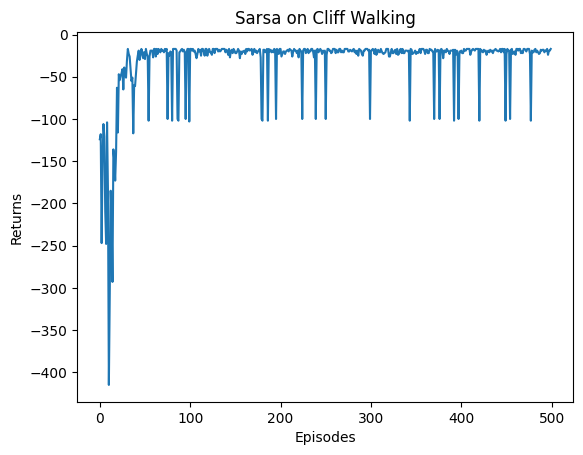

Sarsa算法最终收敛得到的策略为：
ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo 
^ooo ^ooo ^ooo oo<o ^ooo ^ooo ^ooo ^ooo ooo> ooo> ^ooo ovoo 
ooo> ^ooo ^ooo ^ooo ^ooo ^ooo ^ooo ooo> ooo> ^ooo ooo> ovoo 
^ooo **** **** **** **** **** **** **** **** **** **** EEEE 


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  # tqdm是显示循环进度条的库


class CliffWalkingEnv:
    def __init__(self, ncol, nrow):
        self.nrow = nrow
        self.ncol = ncol
        self.x = 0  # 记录当前智能体位置的横坐标
        self.y = self.nrow - 1  # 记录当前智能体位置的纵坐标

    def step(self, action):  # 外部调用这个函数来改变当前位置
        # 4种动作, change[0]:上, change[1]:下, change[2]:左, change[3]:右。坐标系原点(0,0)
        # 定义在左下角
        change = [[0, -1], [0, 1], [-1, 0], [1, 0]]
        self.x = min(self.ncol - 1, max(0, self.x + change[action][0]))
        self.y = min(self.nrow - 1, max(0, self.y + change[action][1]))
        next_state = self.y * self.ncol + self.x
        reward = -1
        done = False
        if self.y == self.nrow - 1 and self.x > 0:  # 下一个位置在悬崖或者目标
            done = True
            if self.x != self.ncol - 1:
                reward = -100
        return next_state, reward, done

    def reset(self):  # 回归初始状态,坐标轴原点在左上角
        self.x = 0
        self.y = self.nrow - 1
        return self.y * self.ncol + self.x
    
class Sarsa:
    """ Sarsa算法 """
    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])  # 初始化Q(s,a)表格
        self.n_action = n_action  # 动作个数
        self.alpha = alpha  # 学习率
        self.gamma = gamma  # 折扣因子
        self.epsilon = epsilon  # epsilon-贪婪策略中的参数

    def take_action(self, state):  # 选取下一步的操作,具体实现为epsilon-贪婪
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action

    def best_action(self, state):  # 用于打印策略
        Q_max = np.max(self.Q_table[state])
        a = [0 for _ in range(self.n_action)]
        for i in range(self.n_action):  # 若两个动作的价值一样,都会记录下来
            if self.Q_table[state, i] == Q_max:
                a[i] = 1
        return a

    def update(self, s0, a0, r, s1, a1):
        td_error = r + self.gamma * self.Q_table[s1, a1] - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td_error
class nstep_Sarsa:
    """ n步Sarsa算法 """
    def __init__(self, n, ncol, nrow, epsilon, alpha, gamma, n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])
        self.n_action = n_action
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n = n  # 采用n步Sarsa算法
        self.state_list = []  # 保存之前的状态
        self.action_list = []  # 保存之前的动作
        self.reward_list = []  # 保存之前的奖励

    def take_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action

    def best_action(self, state):  # 用于打印策略
        Q_max = np.max(self.Q_table[state])
        a = [0 for _ in range(self.n_action)]
        for i in range(self.n_action):
            if self.Q_table[state, i] == Q_max:
                a[i] = 1
        return a

    def update(self, s0, a0, r, s1, a1, done):
        self.state_list.append(s0)
        self.action_list.append(a0)
        self.reward_list.append(r)
        if len(self.state_list) == self.n:  # 若保存的数据可以进行n步更新
            G = self.Q_table[s1, a1]  # 得到Q(s_{t+n}, a_{t+n})
            for i in reversed(range(self.n)):
                G = self.gamma * G + self.reward_list[i]  # 不断向前计算每一步的回报
                # 如果到达终止状态,最后几步虽然长度不够n步,也将其进行更新
                if done and i > 0:
                    s = self.state_list[i]
                    a = self.action_list[i]
                    self.Q_table[s, a] += self.alpha * (G - self.Q_table[s, a])
            s = self.state_list.pop(0)  # 将需要更新的状态动作从列表中删除,下次不必更新
            a = self.action_list.pop(0)
            self.reward_list.pop(0)
            # n步Sarsa的主要更新步骤
            self.Q_table[s, a] += self.alpha * (G - self.Q_table[s, a])
        if done:  # 如果到达终止状态,即将开始下一条序列,则将列表全清空
            self.state_list = []
            self.action_list = []
            self.reward_list = []   

n = 5
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = nstep_Sarsa(n,ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500  # 智能体在环境中运行的序列的数量

return_list = []  # 记录每一条序列的回报
for i in range(10):  # 显示10个进度条
    # tqdm的进度条功能
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):  # 每个进度条的序列数
            episode_return = 0
            state = env.reset()
            action = agent.take_action(state)
            done = False
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state)
                episode_return += reward  # 这里回报的计算不进行折扣因子衰减
                agent.update(state, action, reward, next_state, next_action , done)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Sarsa on {}'.format('Cliff Walking'))
plt.show()
def print_agent(agent, env, action_meaning, disaster=[], end=[]):
    for i in range(env.nrow):
        for j in range(env.ncol):
            if (i * env.ncol + j) in disaster:
                print('****', end=' ')
            elif (i * env.ncol + j) in end:
                print('EEEE', end=' ')
            else:
                a = agent.best_action(i * env.ncol + j)
                pi_str = ''
                for k in range(len(action_meaning)):
                    pi_str += action_meaning[k] if a[k] > 0 else 'o'
                print(pi_str, end=' ')
        print()


action_meaning = ['^', 'v', '<', '>']
print('Sarsa算法最终收敛得到的策略为：')
print_agent(agent, env, action_meaning, list(range(37, 47)), [47])

### Dyna-Q

Q-planning步数为：0


Iteration 9: 100%|██████████| 30/30 [00:00<00:00, 4023.83it/s, episode=300, return=80.200]


^o<o ovoo ovoo ooo> ^ooo ovoo ^ooo ovoo ooo> ^ooo ooo> ovoo ooo> ooo> ooo> oo<o 
ooo> ovoo ovoo oo<o oo<o ^ooo ^ooo ^ooo ^ooo ooo> ^ooo oo<o ooo> ^ooo ooo> ooo> 
oo<o ooo> ovoo **** **** ^ooo ovoo **** **** **** **** **** **** **** **** **** 
^ooo ovoo oo<o **** **** ovoo ovoo ovoo ovoo ovoo ovoo ovoo ovoo ovoo oo<o oo<o 
ovoo ovoo ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo ovoo oo<o oo<o **** ^ooo 
oo<o oo<o ooo> ^ooo ^ooo ^ooo **** **** **** **** ovoo ovoo oo<o ovoo **** ooo> 
oo<o ovoo ^ooo ooo> ^ooo ^ooo **** **** **** **** ooo> ovoo oo<o ooo> **** ooo> 
oo<o ^ooo ooo> ooo> ^ooo ^ooo **** **** **** **** oo<> EEEE oo<> ov<> **** ooo> 
oo<o oo<o oo<o ooo> ooo> ^ooo **** **** **** **** ooo> ^ooo oo<o ^v<> **** ooo> 
oo<o ovoo ooo> ooo> ^ooo ^ooo **** **** ooo> ooo> ^ooo ^oo> oo<> ^v<> **** ^ooo 
oo<o ^ooo ovoo ovoo ovoo ovoo **** **** ^ooo **** **** **** **** **** **** ooo> 
ooo> oo<o oo<o ooo> ovoo ovoo **** **** ^ooo oo<o ooo> ovoo oo<o ooo> oo<o ovoo 
ooo> oo<o ooo> ooo> ooo> ooo

Iteration 9: 100%|██████████| 30/30 [00:00<00:00, 104.75it/s, episode=300, return=86.000]  


ooo> oo<o ovoo ovoo ooo> ovoo ovoo ooo> oo<o ooo> ooo> ^ooo ^ooo oo<o ^ooo ooo> 
oo<o ooo> oo<o oo<o ooo> ovoo ovoo oo<o oo<o ^ooo oo<o oo<o ^ooo ^ooo oo<o ooo> 
^ooo ^ooo oo<o **** **** ooo> ovoo **** **** **** **** **** **** **** **** **** 
^ooo ^ooo ovoo **** **** ovoo ovoo ovoo ovoo ovoo ovoo ovoo ovoo oo<o oo<o oo<o 
^ooo ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo ovoo ovoo ovoo **** ^ooo 
ovoo ooo> ^ooo ooo> ooo> ^ooo **** **** **** **** ooo> ovoo oo<o oo<o **** ^ooo 
oo<o ^ooo ooo> ooo> ooo> ^ooo **** **** **** **** ^ooo ovoo oo<o ^ooo **** ^ooo 
ooo> ooo> ^ooo ^ooo ^ooo ^ooo **** **** **** **** ovoo EEEE ^ooo ^v<> **** ^ooo 
^ooo oo<o ^ooo ^ooo ^ooo ^ooo **** **** **** **** ooo> ^ooo ^v<> ^v<> **** ^ooo 
ovoo oo<o ooo> ovoo ovoo ovoo **** **** ooo> ooo> ^ooo ^ooo ^v<> ^v<> **** ooo> 
^ooo ooo> ooo> ovoo ovoo ovoo **** **** ^ooo **** **** **** **** **** **** ^ooo 
^ooo ooo> ooo> ooo> ovoo ovoo **** **** ^ooo oo<o oo<o oo<o ooo> ooo> ooo> ooo> 
oo<o ^ooo ooo> ^ooo ooo> ooo

Iteration 9: 100%|██████████| 30/30 [00:02<00:00, 11.25it/s, episode=300, return=-923.800]


ooo> ooo> ovoo ooo> ooo> ovoo ovoo ovoo oo<o oo<o oo<o ovoo ovoo ovoo ovoo ooo> 
ooo> ovoo ooo> ooo> ooo> ovoo ovoo oo<o oo<o oo<o oo<o oo<> oo<> ov<> oo<> ov<> 
ooo> ooo> ovoo **** **** ooo> ovoo **** **** **** **** **** **** **** **** **** 
ovoo ooo> ovoo **** **** ooo> ovoo ooo> ooo> ooo> ovoo ovoo ovoo ovoo ^v<> ov<> 
ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo oo<o oo<o oo<o **** ov<> 
ooo> ooo> ooo> ^ooo ooo> ^ooo **** **** **** **** ovoo oo<o ^ooo ^ooo **** ov<> 
ooo> ooo> ^ooo ^ooo ooo> ^ooo **** **** **** **** ovoo ^ooo ^v<> ^v<> **** ov<> 
ooo> ovoo ovoo ovoo ovoo ovoo **** **** **** **** ovoo EEEE ^v<> ^v<> **** ooo> 
ovoo ooo> ooo> ovoo ovoo ovoo **** **** **** **** ovoo ^ooo ^v<> ^v<> **** ovoo 
ooo> ooo> ooo> ovoo ovoo ovoo **** **** ooo> ooo> ooo> ^ooo ^v<> ^v<> **** ovoo 
ooo> ooo> ooo> ooo> ooo> ovoo **** **** ^ooo **** **** **** **** **** **** ovoo 
ooo> ooo> ooo> ooo> ooo> ovoo **** **** ^ooo oo<o oo<o oo<o oo<o oo<o oo<o oo<o 
ooo> ooo> ooo> ooo> ooo> ooo

Iteration 9: 100%|██████████| 30/30 [01:52<00:00,  3.74s/it, episode=300, return=84.000]


ooo> ooo> ooo> ovo> ovo> ovo> ovoo ov<o ov<o oo<> ^v<> ^v<> ^v<> ^v<> ^v<> ^v<> 
ovoo ovoo ovo> ooo> ooo> ovo> ovoo oo<o oo<o oo<> ^v<> ^v<> ^v<> ^v<> ^v<> ^v<> 
ooo> ovo> ovoo **** **** ovo> ovoo **** **** **** **** **** **** **** **** **** 
ovo> ovo> ovoo **** **** ovo> ovo> ovo> ovo> ovo> ovo> ovoo ovoo ov<> ^v<> ov<> 
ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovo> ovoo ov<o ovoo **** ov<> 
^oo> ^oo> ^oo> ^oo> ^oo> ^ooo **** **** **** **** ooo> ovoo ov<o oo<o **** ov<> 
ooo> ^oo> ^oo> ^oo> ^oo> ^ooo **** **** **** **** ^ooo ovoo oo<o ^ooo **** ov<> 
^oo> ^oo> ^oo> ^oo> ^oo> ^ooo **** **** **** **** ^ooo EEEE ^ooo ^v<> **** ov<> 
^oo> ^oo> ^oo> ^oo> ^oo> ^ooo **** **** **** **** ^ooo ^v<> ^v<> ^v<> **** ov<> 
ooo> ^oo> ^oo> ^oo> ^oo> ^ooo **** **** ooo> ooo> ^ooo ^v<> ^v<> ^v<> **** ov<> 
ooo> ^oo> ^oo> ^ooo ^oo> ^ooo **** **** ^ooo **** **** **** **** **** **** ovoo 
ooo> ^ooo ^ooo ^ooo ^ooo ^ooo **** **** ^ooo oo<o oo<o oo<o oo<o oo<o oo<o oo<o 
ooo> ooo> ooo> ooo> ooo> ooo

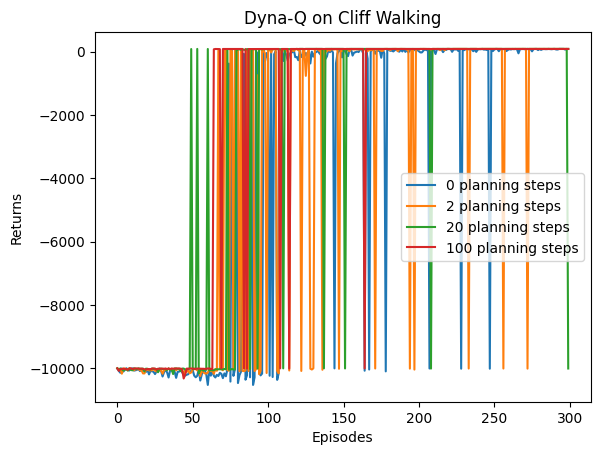

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm 
import time

rng = np.random.default_rng(42)

class CliffWalkingEnv:
    def __init__(self , ncol = 16 , nrow = 16):
        self.ncol = ncol
        self.nrow = nrow
        self.hole_pos = [35,36,51,52]
        self.end = []
        self.hole_pos.extend(range(39,48))
        self.hole_pos.extend(range(243,253))
        self.hole_pos.extend([i*self.ncol+j for i in range(5,9) for j in range(6,10)])
        self.hole_pos.extend([i*self.ncol+j for i in range(9,12) for j in range(6,8)])
        self.hole_pos.extend(range(169,175))
        self.hole_pos.extend(i*self.ncol + 14 for i in range(4,10))
        self.end.append(123)
        self.x = 3
        self.y = 10 #定义起始位置
    
    def step(self,action):
        #分别对应上，下，左，右
        change = [[0,-1],[0,1],[-1,0],[1,0]]
        self.x = min(self.ncol - 1 , max(0 , self.x + change[action][0]))
        self.y = min(self.nrow - 1 , max(0 , self.y + change[action][1]))
        next_state = self.y * self.ncol + self.x
        reward = - 1
        done = False
        if self.y * self.ncol + self.x in self.end:
            done = True
            reward = 100
        elif self.y * self.ncol + self.x in self.hole_pos:
            done = True
            reward = 0
        if next_state in self.hole_pos:
            reward = -10000
        
        return next_state,reward,done
    
    def reset(self):
        self.x = 3
        self.y = 10
        return self.y * self.ncol + self.x
# class CliffWalkingEnv:
#     def __init__(self, ncol, nrow):
#         self.nrow = nrow
#         self.ncol = ncol
#         self.x = 0  # 记录当前智能体位置的横坐标
#         self.y = self.nrow - 1  # 记录当前智能体位置的纵坐标

#     def step(self, action):  # 外部调用这个函数来改变当前位置
#         # 4种动作, change[0]:上, change[1]:下, change[2]:左, change[3]:右。坐标系原点(0,0)
#         # 定义在左上角
#         change = [[0, -1], [0, 1], [-1, 0], [1, 0]]
#         self.x = min(self.ncol - 1, max(0, self.x + change[action][0]))
#         self.y = min(self.nrow - 1, max(0, self.y + change[action][1]))
#         next_state = self.y * self.ncol + self.x
#         reward = -1
#         done = False
#         if self.y == self.nrow - 1 and self.x > 0:  # 下一个位置在悬崖或者目标
#             done = True
#             if self.x != self.ncol - 1:
#                 reward = -100
#         return next_state, reward, done

    def reset(self):
        self.x = 3
        self.y = 10
        return self.y * self.ncol + self.x

class DynaQ:
    """ Dyna-Q算法 """
    def __init__(self,
                 ncol,
                 nrow,
                 epsilon,
                 alpha,
                 gamma,
                 n_planning,
                 n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])  # 初始化Q(s,a)表格
        self.n_action = n_action  # 动作个数
        self.alpha = alpha  # 学习率
        self.gamma = gamma  # 折扣因子
        self.epsilon = epsilon  # epsilon-贪婪策略中的参数

        self.n_planning = n_planning  #执行Q-planning的次数, 对应1次Q-learning
        self.model = dict()  # 环境模型

    def take_action(self, state):  # 选取下一步的操作
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    def best_action(self, state):  # 用于打印策略
        Q_max = np.max(self.Q_table[state])
        a = [0 for _ in range(self.n_action)]
        for i in range(self.n_action):
            if self.Q_table[state, i] == Q_max:
                a[i] = 1
        return a

    def q_learning(self, s0, a0, r, s1):
        td_error = r + self.gamma * self.Q_table[s1].max(
        ) - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td_error

    def update(self, s0, a0, r, s1):
        self.q_learning(s0, a0, r, s1)
        self.model[(s0, a0)] = r, s1  # 将数据添加到模型中
        for _ in range(self.n_planning):  # Q-planning循环
            # 随机选择曾经遇到过的状态动作对
            (s, a), (r, s_) = rng.choice(list(self.model.items()))
            self.q_learning(s, a, r, s_)

def print_agent(agent, env, action_meaning, disaster=[], end=[]):
    for i in range(env.nrow):
        for j in range(env.ncol):
            if (i * env.ncol + j) in disaster:
                print('****', end=' ')
            elif (i * env.ncol + j) in end:
                print('EEEE', end=' ')
            else:
                a = agent.best_action(i * env.ncol + j)
                pi_str = ''
                for k in range(len(action_meaning)):
                    pi_str += action_meaning[k] if a[k] > 0 else 'o'
                print(pi_str, end=' ')
        print()

def DynaQ_CliffWalking(n_planning):
    ncol = 16
    nrow = 16
    env = CliffWalkingEnv(ncol, nrow)
    epsilon = 0.01
    alpha = 0.1
    gamma = 0.9
    agent = DynaQ(ncol, nrow, epsilon, alpha, gamma, n_planning)
    num_episodes = 300  # 智能体在环境中运行多少条序列

    return_list = []  # 记录每一条序列的回报
    for i in range(10):  # 显示10个进度条
        # tqdm的进度条功能
        with tqdm(total=int(num_episodes / 10),
                  desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes / 10)):  # 每个进度条的序列数
                episode_return = 0
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    next_state, reward, done = env.step(action)
                    episode_return += reward  # 这里回报的计算不进行折扣因子衰减
                    agent.update(state, action, reward, next_state)
                    state = next_state
                return_list.append(episode_return)
                if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                    pbar.set_postfix({
                        'episode':
                        '%d' % (num_episodes / 10 * i + i_episode + 1),
                        'return':
                        '%.3f' % np.mean(return_list[-10:])
                    })
                pbar.update(1)
    print_agent(agent, env, action_meaning, env.hole_pos, env.end)
    return return_list


action_meaning = ['^', 'v', '<', '>']   
n_planning_list = [0, 2, 20, 100]
for n_planning in n_planning_list:
    print('Q-planning步数为：%d' % n_planning)
    time.sleep(0.5)
    return_list = DynaQ_CliffWalking(n_planning)
    episodes_list = list(range(len(return_list)))
    plt.plot(episodes_list,
             return_list,
             label=str(n_planning) + ' planning steps')
    
env = CliffWalkingEnv(ncol = 16, nrow = 16)
agent = DynaQ(ncol = 16, nrow = 16, epsilon = 0.01, alpha = 0.1, gamma = 0.9, n_planning = 20)

plt.legend()
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Dyna-Q on {}'.format('Cliff Walking'))
plt.show()
